# Multi-species LBM in JAX (D2Q9, N chemicals)

This notebook ports the D2Q9 solver to JAX and generalizes Shan-Chen coupling to an arbitrary number of species through a coupling matrix $G_{ab}$. The same code is intended to run on TPU later (`jax.jit` already supports both backends transparently); for now we're on CPU.

What changes from the NumPy `d2q9.ipynb`:

- **Backend**: `numpy` -> `jax.numpy`, hot per-step function wrapped in `@jax.jit`. Everything else stays the same shape.
- **Distributions**: shape becomes `(S, 9, Ny, Nx)` for $S$ species so we can vectorize over species cleanly.
- **Coupling**: scalar $G_{ab}$ becomes an $S \times S$ matrix. Off-diagonal sign controls attraction vs. repulsion of each pair; the diagonal is left at zero here (it would model intra-species cohesion / Shan-Chen liquid-vapor).
- **Precision**: we opt into JAX's float64 so per-species mass conservation matches the NumPy reference at $10^{-13}$. On TPU we'd typically switch back to float32 / bfloat16.

After validating that single-species and 2-species reproduce the previous notebooks' numbers, we run two N=3 demos: full mutual repulsion (ternary domains) and a mixed coupling that gives A+C encapsulated by B.


In [1]:
from functools import partial
import time

from jax import config
config.update("jax_enable_x64", True)   # high-precision for validations on CPU

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

print("JAX", jax.__version__, "device:", jax.devices()[0])
rng = np.random.default_rng(0)


JAX 0.10.1 device: cpu:0


## Core operators (vectorized over $S$ species)

We keep the distribution as `f[s, i, y, x]` (species, velocity, y, x). All operations are vectorized over the leading species axis, so single-species ($S=1$) is just a special case.


In [2]:
# D2Q9 lattice
C_np = np.array([
    [ 0,  0], [ 1,  0], [ 0,  1], [-1,  0], [ 0, -1],
    [ 1,  1], [-1,  1], [-1, -1], [ 1, -1],
], dtype=np.int32)
W_np = np.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36])
CS2  = 1/3

C = jnp.asarray(C_np)
W = jnp.asarray(W_np)


def equilibrium(rho, ux, uy):
    # rho, ux, uy: (S, Ny, Nx)  ->  f: (S, 9, Ny, Nx)
    cu = (
        C[None, :, 0, None, None] * ux[:, None, :, :] +
        C[None, :, 1, None, None] * uy[:, None, :, :]
    )
    u2 = ux * ux + uy * uy
    return W[None, :, None, None] * rho[:, None, :, :] * (
        1.0 + cu / CS2 + 0.5 * cu * cu / (CS2 * CS2) - 0.5 * u2[:, None, :, :] / CS2
    )


def macroscopic(f):
    rho = f.sum(axis=1)
    ux  = (C[None, :, 0, None, None] * f).sum(axis=1) / rho
    uy  = (C[None, :, 1, None, None] * f).sum(axis=1) / rho
    return rho, ux, uy


def stream(f):
    # f: (S, 9, Ny, Nx).  Per-velocity periodic roll along (y, x).
    rolled = [
        jnp.roll(f[:, i], shift=(int(C_np[i, 1]), int(C_np[i, 0])), axis=(-2, -1))
        for i in range(9)
    ]
    return jnp.stack(rolled, axis=1)


def viscosity(tau):
    return CS2 * (tau - 0.5)


## Shan-Chen forcing with an arbitrary $S \times S$ coupling matrix

For each species $a$, the force is a sum over partner species $b$:

$$ \mathbf F_a(\mathbf x) = -\rho_a(\mathbf x) \sum_{b=1}^{S} G_{ab} \sum_i w_i\, \rho_b(\mathbf x + \mathbf c_i)\, \mathbf c_i $$

We use $\psi(\rho) = \rho$ for simplicity. The inner $\sum_i w_i\, \rho_b(\mathbf x + \mathbf c_i)\, \mathbf c_i$ is a per-species "neighbor-weighted gradient" field that we compute once per step and reuse across all $a$'s through the matrix multiply by $G$.

Sign convention with $\psi = \rho$: Taylor-expanding gives $\mathbf F_a \approx -G_{ab}\, c_s^2\, \rho_a \nabla \rho_b$, so $G_{ab} > 0$ means species $a$ is pushed away from where $\rho_b$ is rising (repulsion of unlike species; promotes phase separation). $G_{ab} < 0$ flips to attraction.

For a symmetric $G$, the pairwise interactions satisfy Newton's 3rd law and the total force on the domain is zero.


In [3]:
def shan_chen_forces(rho, G):
    # rho: (S, Ny, Nx),  G: (S, S)  ->  F: (S, 2, Ny, Nx).  Skip the rest velocity (no contribution).
    neighbors = [
        jnp.roll(rho, shift=(-int(C_np[i, 1]), -int(C_np[i, 0])), axis=(-2, -1))
        for i in range(1, 9)
    ]
    neighbors = jnp.stack(neighbors)          # (8, S, Ny, Nx)
    Wm = W[1:]                                # (8,)
    Cm = C[1:, :].astype(rho.dtype)           # (8, 2)
    field = jnp.einsum('i,ia,isyx->sayx', Wm, Cm, neighbors)   # (S, 2, Ny, Nx)
    G_sum = jnp.einsum('sb,bayx->sayx', G, field)
    return -rho[:, None, :, :] * G_sum


@partial(jax.jit, static_argnames=('tau',))
def step(f, G, tau):
    rho, ux, uy = macroscopic(f)
    F = shan_chen_forces(rho, G)
    # Mass-weighted common velocity (equal tau for all species)
    rho_tot = rho.sum(axis=0)
    ucx = (rho * ux).sum(axis=0) / rho_tot
    ucy = (rho * uy).sum(axis=0) / rho_tot
    # Velocity-shift forcing: u_eff = u_common + tau F / rho
    ueffx = ucx[None, :, :] + tau * F[:, 0, :, :] / rho
    ueffy = ucy[None, :, :] + tau * F[:, 1, :, :] / rho
    feq = equilibrium(rho, ueffx, ueffy)
    f = f - (f - feq) / tau
    return stream(f), rho


## Validation 1 - uniform equilibrium is a fixed point ($S = 1$)

Same trivial test as before, run through the multi-species machinery with $S = 1$ to confirm the generalization didn't break the special case.


In [4]:
N = 32
rho0 = jnp.ones((1, N, N))
f = equilibrium(rho0, jnp.zeros((1, N, N)), jnp.zeros((1, N, N)))
G = jnp.zeros((1, 1))
for _ in range(500):
    f, rho = step(f, G, 1.0)
rho_np = np.asarray(rho)
print(f"max |rho - 1| = {np.max(np.abs(rho_np - 1)):.2e}")


max |rho - 1| = 2.22e-16


## Validation 2 - Taylor-Green vortex through the multi-species solver

Same analytical decay as in `d2q9.ipynb`, now run through the new $S$-species code path with $S = 1$ and $G = 0$. The measured viscosity should still match $\nu = c_s^2(\tau - 1/2)$ to roughly $0.02\%$.


In [5]:
N = 64
xs = jnp.arange(N); ys = jnp.arange(N)
X, Y = jnp.meshgrid(xs, ys, indexing='xy')
k = 2 * jnp.pi / N
U_amp = 0.05
tau = 0.8

ux0 = -U_amp * jnp.cos(k * X) * jnp.sin(k * Y)
uy0 =  U_amp * jnp.sin(k * X) * jnp.cos(k * Y)
rho0 = jnp.ones((1, N, N))
f = equilibrium(rho0, ux0[None], uy0[None])
G_zero = jnp.zeros((1, 1))

# Warm up JIT
f, _ = step(f, G_zero, tau); f.block_until_ready()

steps = 2000
energies = np.empty(steps)
f = equilibrium(rho0, ux0[None], uy0[None])
for t in range(steps):
    f, rho = step(f, G_zero, tau)
    _, ux, uy = macroscopic(f)
    energies[t] = float(0.5 * jnp.mean(ux * ux + uy * uy))

t_arr = np.arange(steps)
mask = (t_arr > 50) & (energies > 1e-12)
slope = np.polyfit(t_arr[mask], np.log(energies[mask]), 1)[0]
nu_measured = -slope / (4 * k * k)
nu_predicted = viscosity(tau)
print(f"nu measured  = {float(nu_measured):.6f}")
print(f"nu predicted = {float(nu_predicted):.6f}")
print(f"rel error    = {abs(float(nu_measured) - float(nu_predicted))/float(nu_predicted):.2%}")


nu measured  = 0.100020
nu predicted = 0.100000
rel error    = 0.02%


## A quick speed check vs. NumPy

JIT-compiling the per-step function gives a healthy speedup on CPU. The same JIT'd function is what would land on a TPU later.


In [6]:
# Reuse the NumPy reference inline for an apples-to-apples comparison
Ny, Nx = 128, 128

# JAX
rho0_jax = jnp.ones((1, Ny, Nx))
f_jax = equilibrium(rho0_jax, 0.01 * jnp.cos(2*jnp.pi*jnp.arange(Nx)/Nx)[None, None, :] * jnp.ones((1, Ny, 1)),
                                jnp.zeros((1, Ny, Nx)))
G0 = jnp.zeros((1, 1))
# Warmup
for _ in range(3):
    f_jax, _ = step(f_jax, G0, 1.0)
f_jax.block_until_ready()

t0 = time.time()
for _ in range(1000):
    f_jax, _ = step(f_jax, G0, 1.0)
f_jax.block_until_ready()
t_jax = time.time() - t0

# NumPy reference, same kernel
C_n = C_np; W_n = W_np
def np_eq(rho, ux, uy):
    cu = C_n[:, 0, None, None]*ux + C_n[:, 1, None, None]*uy
    u2 = ux*ux + uy*uy
    return W_n[:, None, None]*rho*(1 + cu/CS2 + 0.5*cu*cu/(CS2*CS2) - 0.5*u2/CS2)
def np_step(f, tau):
    rho = f.sum(0)
    ux  = (C_n[:, 0, None, None]*f).sum(0) / rho
    uy  = (C_n[:, 1, None, None]*f).sum(0) / rho
    feq = np_eq(rho, ux, uy)
    f = f - (f - feq) / tau
    out = np.empty_like(f)
    for i in range(9):
        out[i] = np.roll(f[i], shift=(int(C_n[i, 1]), int(C_n[i, 0])), axis=(0, 1))
    return out

ux_np = 0.01 * np.cos(2*np.pi*np.arange(Nx)/Nx)[None, :] * np.ones((Ny, 1))
f_np = np_eq(np.ones((Ny, Nx)), ux_np, np.zeros((Ny, Nx)))
t0 = time.time()
for _ in range(1000):
    f_np = np_step(f_np, 1.0)
t_numpy = time.time() - t0

print(f"NumPy:  {t_numpy:.2f}s for 1000 steps  ({1000/t_numpy:5.0f} steps/s)")
print(f"JAX:    {t_jax:.2f}s for 1000 steps  ({1000/t_jax:5.0f} steps/s)")
print(f"Speedup: {t_numpy/t_jax:.1f}x")


NumPy:  3.30s for 1000 steps  (  303 steps/s)
JAX:    0.95s for 1000 steps  ( 1047 steps/s)
Speedup: 3.5x


## Validation 3 - $S = 2$ reproduces the previous Shan-Chen demo

Same initial random densities, same $G = 3.0$ between unlike species, same $\tau = 1.0$. We should match the $\sigma(\rho_a - \rho_b) \approx 0.99$ from `d2q9.ipynb`.


sigma(rho_a - rho_b) at t=0:    0.033
sigma(rho_a - rho_b) at t=4000: 0.991
mass drift a: -2.18e-13
mass drift b: -2.17e-13


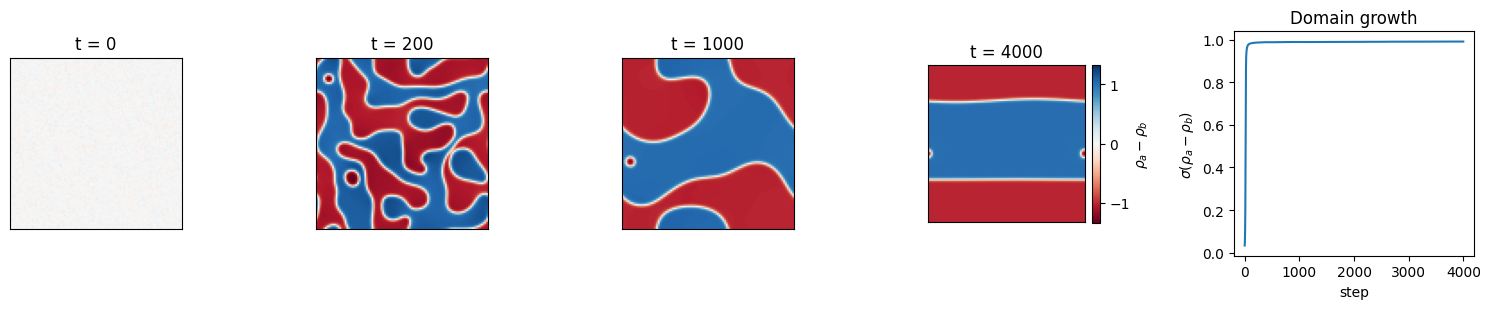

In [7]:
Ny, Nx = 96, 96
tau = 1.0

rho_a0 = 0.5 + 0.03 * rng.standard_normal((Ny, Nx))
rho_b0 = 0.5 + 0.03 * rng.standard_normal((Ny, Nx))
rho_init = jnp.asarray(np.stack([rho_a0, rho_b0]))
zeros = jnp.zeros((2, Ny, Nx))
f = equilibrium(rho_init, zeros, zeros)
G2 = jnp.asarray([[0.0, 3.0],
                  [3.0, 0.0]])

snap_steps = (0, 200, 1000, 4000)
snaps = {}
sep_history = []
total_steps = max(snap_steps)
for t in range(total_steps + 1):
    if t in snap_steps:
        rho = np.asarray(f.sum(axis=1))
        snaps[t] = rho[0] - rho[1]
    if t == total_steps:
        break
    f, rho = step(f, G2, tau)
    if t > 0:
        sep_history.append(float(jnp.std(rho[0] - rho[1])))

print(f"sigma(rho_a - rho_b) at t=0:    {sep_history[0]:.3f}")
print(f"sigma(rho_a - rho_b) at t={total_steps}: {sep_history[-1]:.3f}")
print(f"mass drift a: {(float(np.asarray(rho[0]).sum()) - rho_a0.sum())/rho_a0.sum():.2e}")
print(f"mass drift b: {(float(np.asarray(rho[1]).sum()) - rho_b0.sum())/rho_b0.sum():.2e}")

fig, axs = plt.subplots(1, 5, figsize=(15, 3.2),
                        gridspec_kw={'width_ratios': [1, 1, 1, 1, 1.4]})
vmax = max(abs(s).max() for s in snaps.values())
for ax, t_snap in zip(axs[:4], sorted(snaps)):
    im = ax.imshow(snaps[t_snap], origin='lower', cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(f't = {t_snap}')
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axs[3], fraction=0.046, pad=0.04, label=r'$\rho_a - \rho_b$')
axs[4].plot(np.arange(len(sep_history)), sep_history)
axs[4].set_xlabel('step')
axs[4].set_ylabel(r'$\sigma(\rho_a - \rho_b)$')
axs[4].set_title('Domain growth')
plt.tight_layout()
plt.show()


## $S = 3$, demo 1 - ternary domains from mutual repulsion

Three species with all pairwise $G_{ab} = 2.0$ (and zero diagonal). Symmetric coupling, all unlike pairs repel each other equally, so the system separates into three coexisting phases. Initialized at $\rho \approx 1/3$ each with small noise.


Final density ranges:
  species 0: rho in [0.016, 1.070]
  species 1: rho in [0.016, 1.062]
  species 2: rho in [0.016, 1.063]
corr(0,1) = -0.488
corr(0,2) = -0.488
corr(1,2) = -0.487
mass drift species 0: -3.23e-13
mass drift species 1: -3.23e-13
mass drift species 2: -3.24e-13


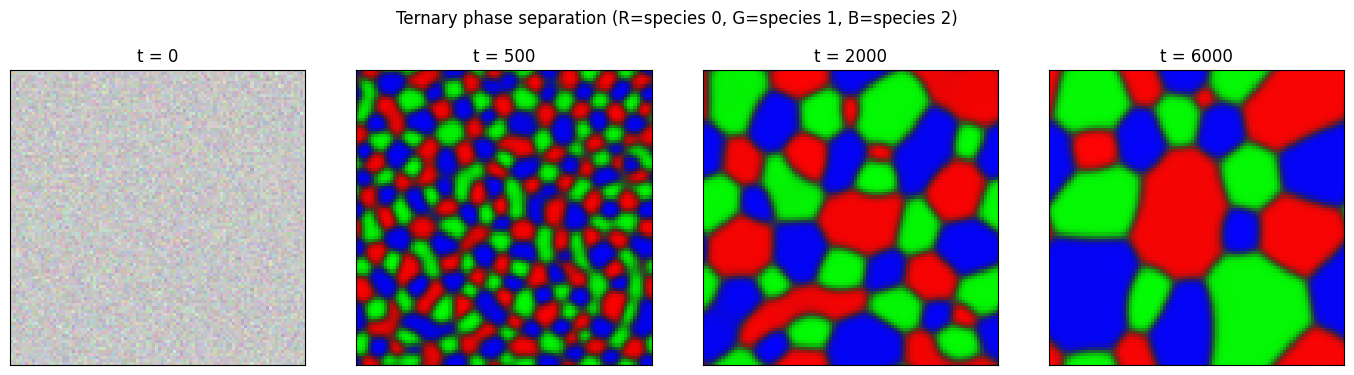

In [8]:
Ny, Nx = 96, 96
S = 3
tau = 1.0
mean_rho = 1.0 / S

rho0 = np.stack([mean_rho + 0.02 * rng.standard_normal((Ny, Nx)) for _ in range(S)])
rho0_j = jnp.asarray(rho0)
zeros3 = jnp.zeros((S, Ny, Nx))
f = equilibrium(rho0_j, zeros3, zeros3)

# Off-diagonal repulsion only
G3 = jnp.asarray([[0.0, 2.0, 2.0],
                  [2.0, 0.0, 2.0],
                  [2.0, 2.0, 0.0]])

snap_steps = (0, 500, 2000, 6000)
snaps = {0: rho0.copy()}
for t in range(1, max(snap_steps) + 1):
    f, rho = step(f, G3, tau)
    if t in snap_steps:
        snaps[t] = np.asarray(rho)

# Each species' final density range, and pairwise correlations
final = snaps[max(snap_steps)]
print("Final density ranges:")
for s in range(S):
    print(f"  species {s}: rho in [{final[s].min():.3f}, {final[s].max():.3f}]")
print(f"corr(0,1) = {np.corrcoef(final[0].flatten(), final[1].flatten())[0,1]:+.3f}")
print(f"corr(0,2) = {np.corrcoef(final[0].flatten(), final[2].flatten())[0,1]:+.3f}")
print(f"corr(1,2) = {np.corrcoef(final[1].flatten(), final[2].flatten())[0,1]:+.3f}")
for s in range(S):
    drift = (final[s].sum() - rho0[s].sum()) / rho0[s].sum()
    print(f"mass drift species {s}: {drift:.2e}")

# Composite color image: each species -> a color channel
def rgb_from_species(rho_stack):
    r = rho_stack[0]
    g = rho_stack[1]
    b = rho_stack[2]
    M = max(r.max(), g.max(), b.max())
    return np.stack([r/M, g/M, b/M], axis=-1).clip(0, 1)

fig, axs = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, t_snap in zip(axs, sorted(snaps)):
    ax.imshow(rgb_from_species(snaps[t_snap]), origin='lower')
    ax.set_title(f't = {t_snap}')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Ternary phase separation (R=species 0, G=species 1, B=species 2)', y=1.03)
plt.tight_layout()
plt.show()


## $S = 3$, demo 2 - mixed couplings: A and C attract, both repel B

Now we set $G_{AB} = G_{BC} = +2.0$ (repulsion) but $G_{AC} = -0.2$ (mild attraction). Species A and C should co-locate (they pull on each other) while both are pushed away from B. Result: a binary A+C / B separation, but with A and C mixed within their shared domain. Correlations should land near corr(A, C) = +1 and corr(A, B) = -1.

Stronger attraction is possible too but moves the system toward numerical divergence (the Shan-Chen pseudopotential gives a negative pressure contribution that, beyond a threshold, makes the effective sound speed imaginary). Around $G_{AC} \le -0.4$ tends to blow up on this grid; $-0.2$ leaves comfortable margin.


Final density ranges:
  species A: rho in [0.003, 0.809], mean 0.500
  species B: rho in [0.004, 1.763], mean 0.500
  species C: rho in [0.003, 0.809], mean 0.500
corr(A, B) = -0.959  (expect ~ -1)
corr(A, C) = +1.000  (expect ~ +1)
corr(B, C) = -0.959  (expect ~ -1)


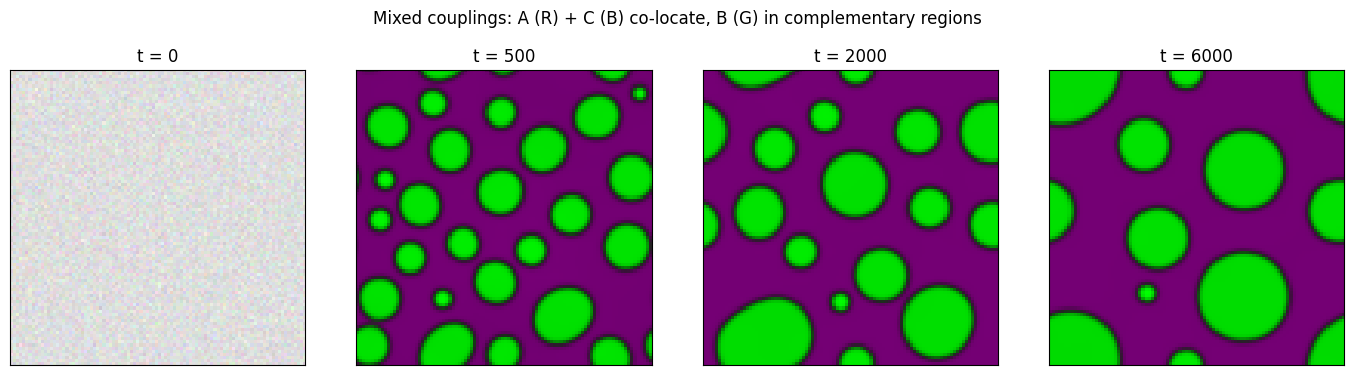

In [9]:
Ny, Nx = 96, 96
S = 3
tau = 1.0

rho0 = np.stack([0.5 + 0.02 * rng.standard_normal((Ny, Nx)) for _ in range(S)])
rho0_j = jnp.asarray(rho0)
zeros3 = jnp.zeros((S, Ny, Nx))
f = equilibrium(rho0_j, zeros3, zeros3)

G3 = jnp.asarray([[ 0.0,  2.0, -0.2],
                  [ 2.0,  0.0,  2.0],
                  [-0.2,  2.0,  0.0]])

snap_steps = (0, 500, 2000, 6000)
snaps = {0: rho0.copy()}
for t in range(1, max(snap_steps) + 1):
    f, rho = step(f, G3, tau)
    if t in snap_steps:
        snaps[t] = np.asarray(rho)

final = snaps[max(snap_steps)]
print("Final density ranges:")
for s, name in zip(range(S), ['A', 'B', 'C']):
    print(f"  species {name}: rho in [{final[s].min():.3f}, {final[s].max():.3f}], mean {final[s].mean():.3f}")
print(f"corr(A, B) = {np.corrcoef(final[0].flatten(), final[1].flatten())[0,1]:+.3f}  (expect ~ -1)")
print(f"corr(A, C) = {np.corrcoef(final[0].flatten(), final[2].flatten())[0,1]:+.3f}  (expect ~ +1)")
print(f"corr(B, C) = {np.corrcoef(final[1].flatten(), final[2].flatten())[0,1]:+.3f}  (expect ~ -1)")

fig, axs = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, t_snap in zip(axs, sorted(snaps)):
    ax.imshow(rgb_from_species(snaps[t_snap]), origin='lower')
    ax.set_title(f't = {t_snap}')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Mixed couplings: A (R) + C (B) co-locate, B (G) in complementary regions', y=1.03)
plt.tight_layout()
plt.show()


## Where this leaves us

We now have a multi-species D2Q9 solver in JAX with:

- Single `@jax.jit` step function that vectorizes over $S$ species and a generic $S \times S$ coupling matrix.
- Validated against the analytical Taylor-Green vortex decay rate and the previous NumPy reference for $S = 2$.
- N=3 demos showing (a) symmetric mutual repulsion producing ternary domains and (b) mixed attract / repel couplings producing co-located + complementary phases.

A few directions worth pursuing next, depending on the goal:

- **TPU dispatch** - no code changes needed; `jax.devices()` will report TPU and `step()` will compile there. Likely we'll want to drop `jax_enable_x64` for performance and accept the float32 mass drift (~$10^{-5}$ over $10^3$ steps), which is fine for the dynamics if not for tight conservation checks.
- **Reactive chemistry** - add source terms $R_a(\boldsymbol{\rho})$ inside the JIT'd step (just an extra $\rho_a \leftarrow \rho_a + \Delta t\, R_a$ before equilibrium). With JAX we'd get `jax.grad` of the whole simulation for free, which is useful if we ever want to fit $G_{ab}$ or reaction rates to data.
- **Entropy / temperature** - either as a passive diagnostic ($H = \sum_i f_i \ln(f_i/w_i)$ per species) or as a coupled thermal distribution $h_i$ that talks back to the fluid through buoyancy.
- **Boundaries** - bounce-back walls and inlet/outlet conditions, since `jax.numpy.roll` only buys us periodic.
- **Scaling** - the current implementation is dense; for very large $S$ a sparse coupling matrix or chunking by species pair would help.
